#### Comparative Setup

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Ensure notebook can see model.py
sys.path.append(os.path.abspath('..'))
from model import LivelihoodModel

# Load the realistic baseline
baseline_df = pd.read_csv('../data/results/baseline_control_results.csv')

print("Logic loaded. Starting the Tournament: Intensification vs. Diversification.")

Logic loaded. Starting the Tournament: Intensification vs. Diversification.


#### Running the Scenarios

In [2]:
scenarios = ["Intensification", "Diversification"]
# Store the Poverty Rate for each run
tournament_data = {"Control": baseline_df['Poverty_Rate']}

for scn in scenarios:
    print(f"Simulating Strategy: {scn}...")
    # Use a fixed seed if you want the exact same price fluctuations for all 3
    model = LivelihoodModel(N=1000, intervention=scn)
    
    for _ in range(60):
        model.step()
    
    res = model.datacollector.get_model_vars_dataframe()
    tournament_data[scn] = res['Poverty_Rate']

# Create a master dataframe for comparison
df_comp = pd.DataFrame(tournament_data)
df_comp.to_csv('../data/results/intervention_tournament_final.csv', index=False)
print("Results saved to data/results/intervention_tournament_final.csv")

Simulating Strategy: Intensification...
Simulating Strategy: Diversification...
Results saved to data/results/intervention_tournament_final.csv


In [3]:
df_comp.head()

,Control,Intensification,Diversification
0,0.226,0.231,0.229
1,0.460,0.470,0.462
2,0.657,0.677,0.644
3,0.809,0.822,0.770
4,0.894,0.909,0.876


#### The Winning Visualization

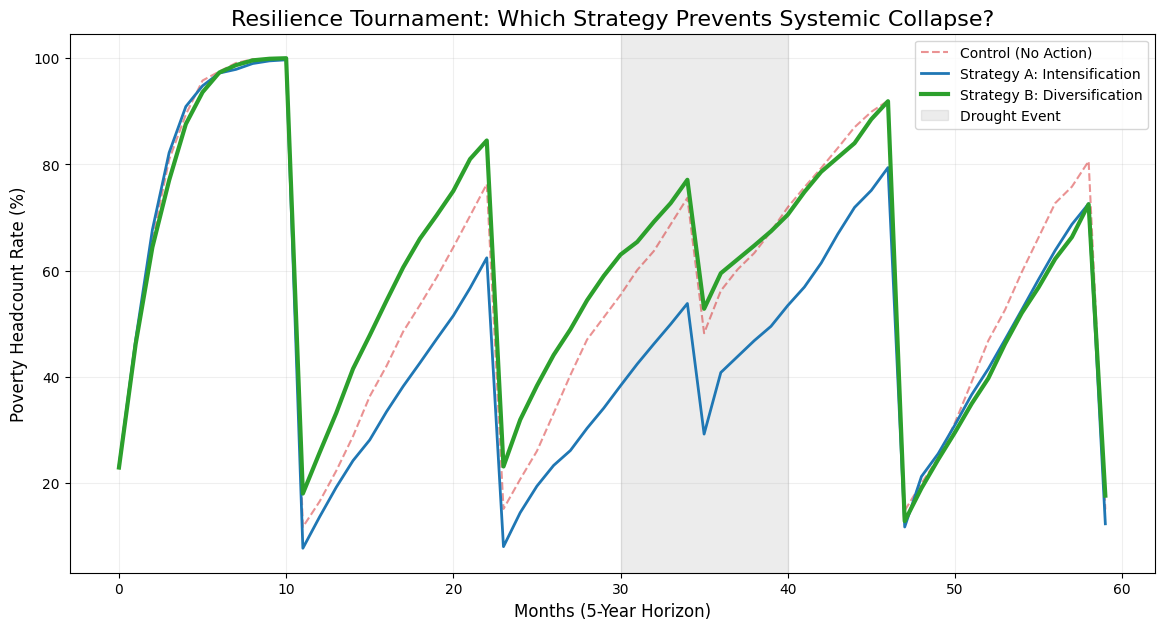

In [4]:
plt.figure(figsize=(14, 7))

# Colors and Linestyles for clarity
plt.plot(df_comp['Control'] * 100, label='Control (No Action)', color='#d62728', linestyle='--', alpha=0.5)
plt.plot(df_comp['Intensification'] * 100, label='Strategy A: Intensification', color='#1f77b4', linewidth=2)
plt.plot(df_comp['Diversification'] * 100, label='Strategy B: Diversification', color='#2ca02c', linewidth=3)

# Add the Drought Zone
plt.axvspan(30, 40, color='gray', alpha=0.15, label='Drought Event')

plt.title("Resilience Tournament: Which Strategy Prevents Systemic Collapse?", fontsize=16)
plt.ylabel("Poverty Headcount Rate (%)", fontsize=12)
plt.xlabel("Months (5-Year Horizon)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

#### The Impact Matrix

In [5]:
impact_stats = []
for strategy in df_comp.columns:
    peak = df_comp[strategy].max() * 100
    final = df_comp[strategy].iloc[-1] * 100
    # Resilience is defined as 100 minus the peak poverty during crisis
    resilience = 100 - peak
    
    impact_stats.append({
        "Intervention": strategy,
        "Peak Poverty (%)": peak,
        "Final Poverty (%)": final,
        "Resilience Score": resilience
    })

pd.DataFrame(impact_stats).set_index("Intervention").round(2)

,Peak Poverty (%),Final Poverty (%),Resilience Score
Intervention,,,
Control,100.0,15.0,0.0
Intensification,99.7,12.3,0.3
Diversification,100.0,17.6,0.0
